# Section 5.6, Figure 1

Measures training loss and the fraction of mask entries that change over time on FashionMNIST.

## Run Notes
- Run the notebook from top to bottom.
- Downloads FashionMNIST on first run.
- Compares the mask model with a classical dense baseline.
- Random sampling is intentionally exposed in the experiment cells so readers can vary it.

## Setup

In [ ]:
import math

import numpy as np
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# Prefer a GPU in Colab, fall back to Apple MPS when available, and use CPU otherwise.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

class ClassicNetwork(nn.Module):
    """Dense baseline with the same layer sizes as the masked model."""

    def __init__(self, layer_sizes, bias=True):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            *[
                block
                for layer in layer_sizes
                for block in [nn.Linear(layer[0], layer[1], bias=bias), nn.ReLU()]
            ][:-1]
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.linear_relu_stack(x)

def signed_kaiming_constant_(
    tensor,
    a=0,
    mode="fan_in",
    nonlinearity="relu",
    k=0.5,
    sparsity=0,
):
    """Initialize frozen weights with signed Kaiming-style uniform samples."""
    fan = nn.init._calculate_correct_fan(tensor, mode)
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = gain / math.sqrt(fan)

    # The active subnetwork keeps a k-fraction of weights, so rescale by 1/sqrt(k).
    if k != 0:
        std *= 1 / math.sqrt(k)

    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            keep_mask = (torch.rand_like(tensor) > sparsity).float()
            tensor *= keep_mask
        return tensor

class GetSubnet(autograd.Function):
    """Straight-through top-k mask used by edge-popup."""

    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Convert scores to a binary mask by keeping the largest k-fraction.
        out = scores.clone()
        _, idx = scores.flatten().sort()
        cutoff = int((1 - k) * scores.numel())
        flat_out = out.flatten()
        flat_out[idx[:cutoff]] = 0
        flat_out[idx[cutoff:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # Straight-through estimator: pass score gradients through unchanged.
        return grad, None

class LinearSubnet(nn.Linear):
    """Linear layer whose training mode controls weights, scores, and masking."""

    def __init__(
        self,
        in_features,
        out_features,
        init=signed_kaiming_constant_,
        k=0.5,
        extra_capacity=0,
        double=True,
        **kwargs,
    ):
        super().__init__(in_features, out_features, **kwargs)
        multiplier = 2 if double else 1
        self.k = k
        self.mode = "mask"

        self.scores = nn.Parameter(
            torch.randn(out_features, multiplier * in_features + extra_capacity)
        )
        init(self.weight)
        self.weight.requires_grad_(False)

        if self.bias is not None:
            self.bias_scores = nn.Parameter(
                torch.randn(multiplier + extra_capacity, out_features)
            )
            self.bias.requires_grad_(False)

    def forward(self, x):
        if self.mode == "static":
            return F.linear(x, self.weight, self.bias)

        weight_mask = GetSubnet.apply(self.scores.abs(), self.k)
        weight = self.weight * weight_mask[:, : self.weight.shape[-1]]

        if self.bias is None:
            return F.linear(x, weight)

        bias_mask = GetSubnet.apply(self.bias_scores.abs(), self.k)
        bias = self.bias * bias_mask[1, : self.bias.shape[-1]]
        return F.linear(x, weight, bias)

    def toggle_mode(self, mode):
        """Switch between score training, dense retraining, joint training, and frozen masks."""
        self.mode = mode
        train_weights = mode in {"classic", "hybrid"}
        train_scores = mode in {"mask", "hybrid"}

        self.weight.requires_grad_(train_weights)
        self.scores.requires_grad_(train_scores)
        if self.bias is not None:
            self.bias.requires_grad_(train_weights)
            self.bias_scores.requires_grad_(train_scores)


class Network(nn.Module):
    """Small MLP assembled from masked LinearSubnet layers."""

    def __init__(
        self,
        layer_sizes,
        init=signed_kaiming_constant_,
        bias=True,
        double=True,
        extra_capacity=0,
    ):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            *[
                block
                for layer in layer_sizes
                for block in [
                    LinearSubnet(
                        layer[0],
                        layer[1],
                        init=init,
                        bias=bias,
                        double=double,
                        extra_capacity=extra_capacity,
                    ),
                    nn.ReLU(),
                ]
            ][:-1]
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

    def toggle_mode(self, mode):
        """Apply a mode change to every masked layer."""
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.toggle_mode(mode)

Using cpu device


## Experiment and Figure

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5



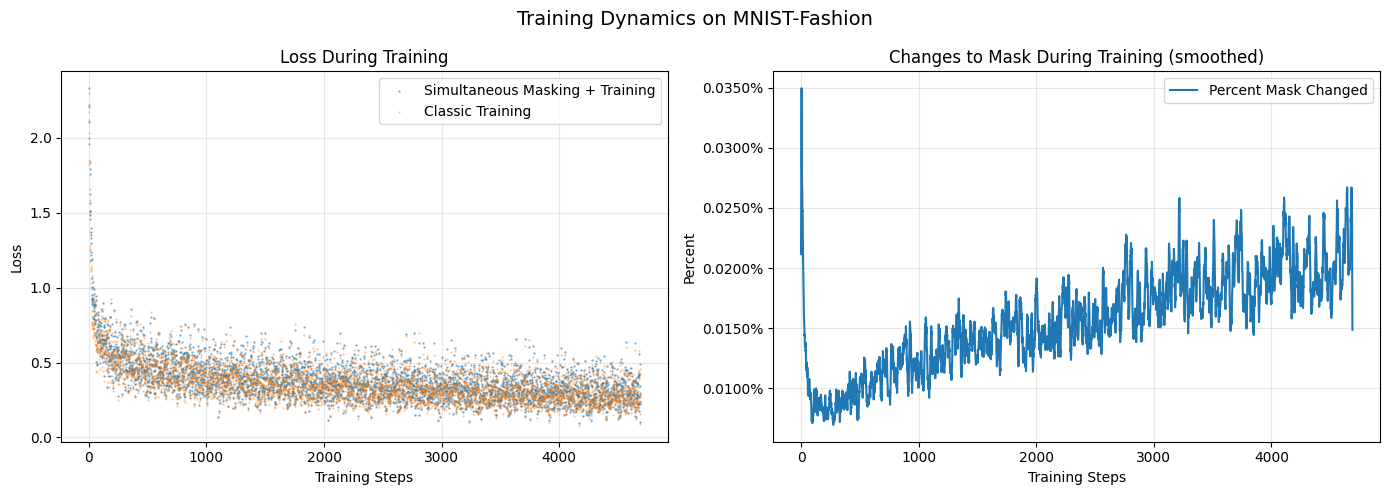

In [ ]:
# Experiment outline:
# 1. Train a hybrid masked model and a dense baseline on FashionMNIST.
# 2. Measure how much the learned mask changes from one batch to the next.
# 3. Plot training loss beside smoothed mask-change dynamics.

epochs = 5
batch_size = 64
layer_sizes=[[28*28,256],[256,10]]

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
train_dataloader = DataLoader(training_data, batch_size=batch_size)
loss_fn = nn.CrossEntropyLoss()
losses = []
classic_losses = []
mask_changes=[]

model = Network(layer_sizes)
model.to(device)
model.toggle_mode('hybrid')
optimizer = torch.optim.Adam(model.parameters())
classic_model = ClassicNetwork(layer_sizes)
classic_model.to(device)
classic_optimizer = torch.optim.Adam(classic_model.parameters())
for t in range(epochs):
    model.train()
    for (X, y) in train_dataloader:
        current_masks = {}
        for layer in model.layers:
          if hasattr(layer, "scores") and hasattr(layer, "weight"):
              current_masks[layer] = (
                  GetSubnet.apply(layer.scores.abs(), layer.k)[:, : layer.weight.shape[-1]].to(device),
                  GetSubnet.apply(layer.bias_scores.abs(), layer.k)[1, : layer.bias.shape[-1]].to(device),
              )
        X,y = X.to(device), y.to(device)
        optimizer.zero_grad()
        classic_optimizer.zero_grad()
        pred,classic_pred = model(X),classic_model(X)
        loss,classic_loss = loss_fn(pred, y),loss_fn(classic_pred, y)
        losses.append(loss.item())
        classic_losses.append(classic_loss.item())
        loss.backward()
        classic_loss.backward()
        optimizer.step()
        classic_optimizer.step()
        curr_changes=0
        for layer in model.layers:
            if hasattr(layer, "scores") and hasattr(layer, "weight"):
                old_mask,old_bmask = current_masks[layer]
                mask = GetSubnet.apply(layer.scores.abs(), layer.k)[:, :layer.weight.shape[-1]].to(device)
                bmask = GetSubnet.apply(layer.bias_scores.abs(), layer.k)[1,:layer.bias.shape[-1]].to(device)
                curr_changes+=((old_mask!=mask).sum()+(old_bmask!=bmask).sum()).item()
        mask_changes.append(curr_changes)



window = 10
total_weights = sum(layer.weight.numel() for layer in model.layers if hasattr(layer, "scores") and hasattr(layer, "weight"))
relative_mask_changes = [m/total_weights for m in mask_changes]
smoothed_mask_changes = np.convolve(relative_mask_changes, np.ones(window)/window, mode='same')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Losses ---
axes[0].scatter([i for i in range(len(losses))],losses, s=0.5, alpha=0.5, label="Simultaneous Masking + Training")
axes[0].scatter([i for i in range(len(losses))],classic_losses, s=0.25, alpha=0.5, label="Classic Training")

axes[0].set_title("Loss During Training")
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Right plot: Mask changes ---
axes[1].plot(
    smoothed_mask_changes,
    label="Percent Mask Changed"
    )

axes[1].set_title("Changes to Mask During Training (smoothed)")
axes[1].set_xlabel("Training Steps")
axes[1].set_ylabel("Percent")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Layout ---
plt.suptitle("Training Dynamics on MNIST-Fashion", fontsize=14)
plt.tight_layout()
plt.show()